<a href="https://colab.research.google.com/github/daniausman24-bot/ML_Internship_Track/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniausman24-bot/ML_Internship_Track/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [ ]:
!git clone https://github.com/daniausman24-bot/ML_Internship_Track.git

Cloning into 'ML_Internship_Track'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 157 (delta 58), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 1.90 MiB | 5.92 MiB/s, done.
Resolving deltas: 100% (58/58), done.


(30000, 44)
Duplicate rows: 0

Target distribution:
 is_declining_label
1    16262
0    13738
Name: count, dtype: int64
Declining rate: 0.5421

Train rows: 23837 | Test rows: 6163
Train clients: 25 | Test clients: 7
Client overlap: 0 (grouped split validation passed)
Train declining rate: 0.5501
Test declining rate: 0.511

Leakage audit passed.

Classification report (threshold 0.5, diagnostic only):
              precision    recall  f1-score   support

           0       0.60      0.44      0.51      3014
           1       0.57      0.73      0.64      3149

    accuracy                           0.58      6163
   macro avg       0.59      0.58      0.57      6163
weighted avg       0.59      0.58      0.58      6163

ROC-AUC: 0.615

Precision@K results:
  K  Baseline Precision@K  Logistic Regression Precision@K
 10                  0.30                             0.80
 20                  0.35                             0.70
 50                  0.46                             0

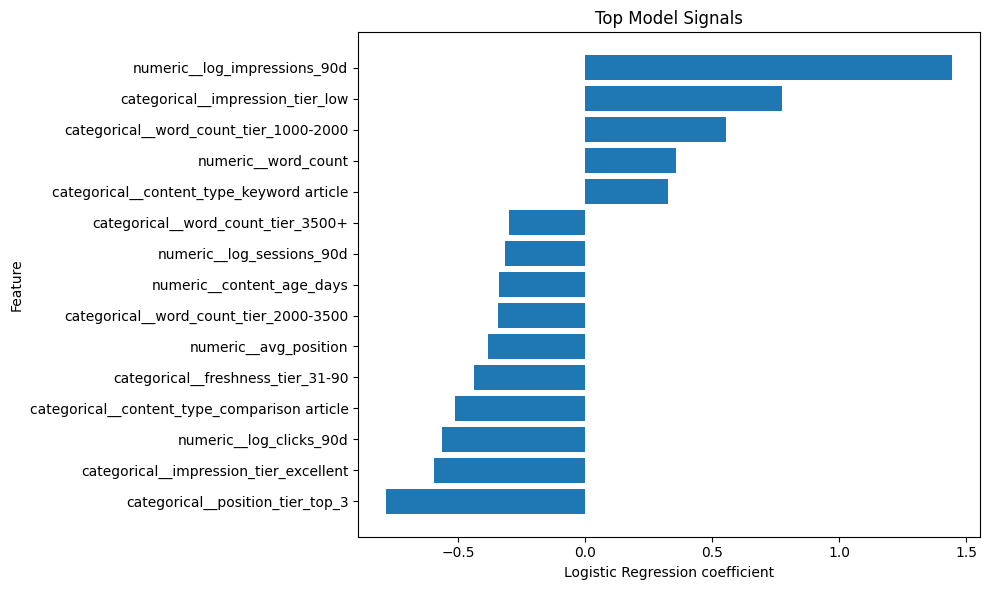

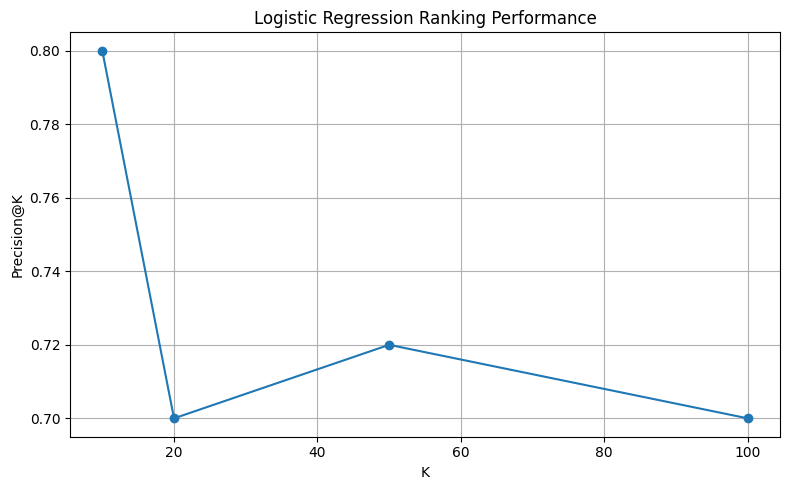

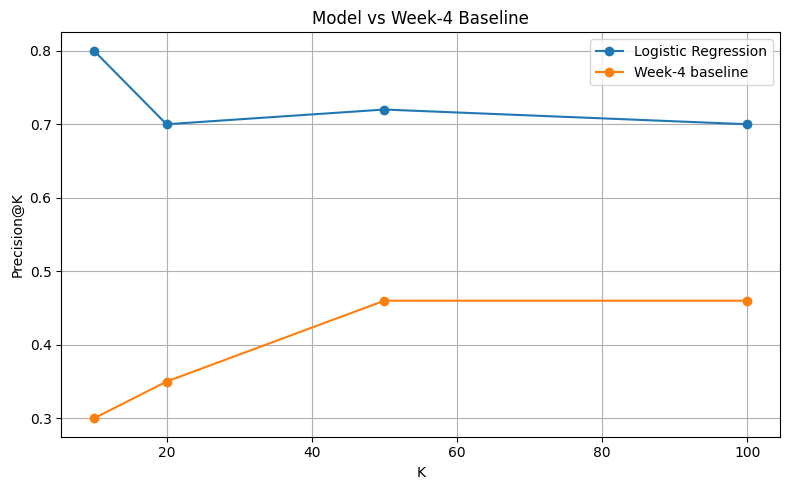

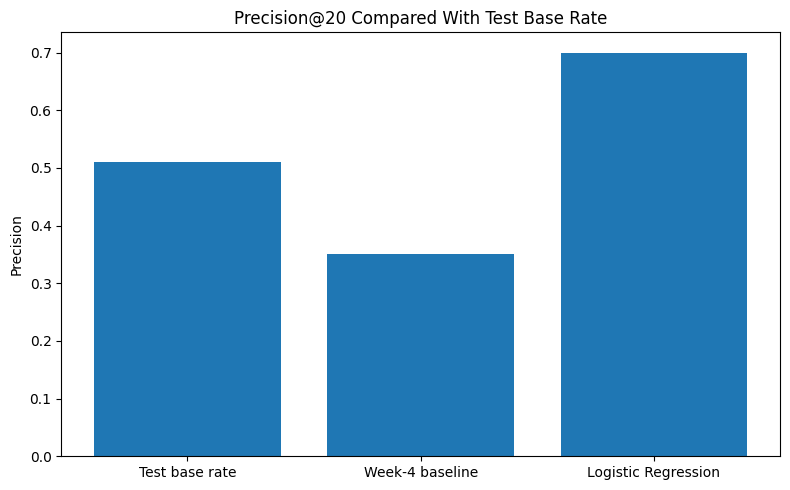


CAPSTONE COMPLETE
Random state: 42
Train rows / clients: 23837 / 25
Test rows / clients: 6163 / 7
Client overlap: 0
Model P@20: 0.700 | Baseline P@20: 0.350
Model P@50: 0.720 | Baseline P@50: 0.460
Test base rate: 0.511
/content/ML_Internship_Track/outputs/capstone_results.csv -> FOUND
/content/ML_Internship_Track/outputs/capstone_action_playbook.csv -> FOUND


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

RANDOM_STATE = 42

# ---------------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------------
data_path = Path("ML_Internship_Track/data/raw/content_refresh_anonymized.csv")

df = pd.read_csv(data_path)

print(df.shape)
df.head()
print("Duplicate rows:", df.duplicated().sum())

# ---------------------------------------------------------------
# 2. Target
# ---------------------------------------------------------------
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
print("\nTarget distribution:\n", df["is_declining_label"].value_counts())
print("Declining rate:", round(df["is_declining_label"].mean(), 4))

# ---------------------------------------------------------------
# 3. Client-grouped split
# ---------------------------------------------------------------
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, df["is_declining_label"], groups=df["client_id"]))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

train_clients = set(train_df["client_id"])
test_clients = set(test_df["client_id"])
assert len(train_clients & test_clients) == 0, "Client leakage between train and test!"

print("\nTrain rows:", len(train_df), "| Test rows:", len(test_df))
print("Train clients:", len(train_clients), "| Test clients:", len(test_clients))
print("Client overlap: 0 (grouped split validation passed)")
print("Train declining rate:", round(train_df["is_declining_label"].mean(), 4))
print("Test declining rate:", round(test_df["is_declining_label"].mean(), 4))

# ---------------------------------------------------------------
# 4. Features + leakage audit
# ---------------------------------------------------------------
for frame in (train_df, test_df):
    frame["log_impressions_90d"] = np.log1p(frame["impressions_90d"])
    frame["log_clicks_90d"] = np.log1p(frame["clicks_90d"])
    frame["log_sessions_90d"] = np.log1p(frame["sessions_90d"])
    frame["log_ai_sessions_90d"] = np.log1p(frame["ai_sessions_90d"])

model_numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "log_ai_sessions_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
]
categorical_features = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]

leakage_columns = {"trend_direction", "is_declining_label", "client_id", "content_id"}
leakage_used = set(model_numeric_features + categorical_features) & leakage_columns
assert len(leakage_used) == 0, f"Leakage columns used: {leakage_used}"
print("\nLeakage audit passed.")

X_train = train_df[model_numeric_features + categorical_features].copy()
X_test = test_df[model_numeric_features + categorical_features].copy()
y_train = train_df["is_declining_label"].copy()
y_test = test_df["is_declining_label"].copy()

# ---------------------------------------------------------------
# 5. Pipeline + Logistic Regression
# ---------------------------------------------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, model_numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)

model_test_probability = model.predict_proba(X_test)[:, 1]
model_test_prediction = (model_test_probability >= 0.5).astype(int)

print("\nClassification report (threshold 0.5, diagnostic only):")
print(classification_report(y_test, model_test_prediction))
print("ROC-AUC:", round(roc_auc_score(y_test, model_test_probability), 4))

# ---------------------------------------------------------------
# 6. Week-4 baseline
# ---------------------------------------------------------------
test_baseline = test_df.copy()
test_baseline["stale_flag"] = (test_baseline["days_since_last_update"] >= 180).astype(int)
test_baseline["visible_flag"] = (test_baseline["impressions_90d"] >= 500).astype(int)
test_baseline["weak_position_flag"] = (
    (test_baseline["avg_position"] > 0) & (test_baseline["avg_position"] >= 10)
).astype(int)
test_baseline["baseline_score"] = (
    test_baseline["stale_flag"] + test_baseline["visible_flag"] + test_baseline["weak_position_flag"]
)

# ---------------------------------------------------------------
# 7. Precision@K
# ---------------------------------------------------------------
def precision_at_k(y_true, scores, k):
    temp = pd.DataFrame({"y": np.asarray(y_true), "score": np.asarray(scores)})
    return temp.sort_values("score", ascending=False).head(k)["y"].mean()

k_values = [10, 20, 50, 100]
model_precision_values = [precision_at_k(y_test, model_test_probability, k) for k in k_values]
baseline_precision_values = [precision_at_k(y_test, test_baseline["baseline_score"], k) for k in k_values]

results_table = pd.DataFrame({
    "K": k_values,
    "Baseline Precision@K": baseline_precision_values,
    "Logistic Regression Precision@K": model_precision_values,
})
print("\nPrecision@K results:")
print(results_table.to_string(index=False))

base_rate = y_test.mean()
model_p20, baseline_p20 = model_precision_values[1], baseline_precision_values[1]
model_p50, baseline_p50 = model_precision_values[2], baseline_precision_values[2]

comparison = pd.DataFrame({
    "Method": ["Week-4 baseline", "Logistic Regression"],
    "Precision@20": [baseline_p20, model_p20],
    "Precision@50": [baseline_p50, model_p50],
    "Test base rate": [base_rate, base_rate],
})
print("\nModel vs baseline:")
print(comparison.to_string(index=False))
print(f"\nP@20 difference: {model_p20 - baseline_p20:.3f}")
print(f"P@50 difference: {model_p50 - baseline_p50:.3f}")
print(f"Test declining base rate: {base_rate:.4f}")

# ---------------------------------------------------------------
# 8. Coefficients
# ---------------------------------------------------------------
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]
importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients),
}).sort_values("absolute_coefficient", ascending=False)

print("\nTop 20 model signals:")
print(importance.head(20)[["feature", "coefficient"]].to_string(index=False))

top_positive = importance[importance["coefficient"] > 0].sort_values("coefficient", ascending=False).head(10)
top_negative = importance[importance["coefficient"] < 0].sort_values("coefficient").head(10)
print("\nTop positive coefficients:")
print(top_positive[["feature", "coefficient"]].to_string(index=False))
print("\nTop negative coefficients:")
print(top_negative[["feature", "coefficient"]].to_string(index=False))

# ---------------------------------------------------------------
# 9. Ranked action playbook
# ---------------------------------------------------------------
ranked_test = test_df.copy()
ranked_test["decline_probability"] = model_test_probability
ranked_test = ranked_test.sort_values("decline_probability", ascending=False).reset_index(drop=True)
ranked_test["rank"] = ranked_test.index + 1

def assign_action(rank):
    if rank <= 20:
        return "Priority review"
    elif rank <= 50:
        return "Review next"
    elif rank <= 100:
        return "Monitor"
    return "Lower priority"

def generate_reason_codes(row):
    reasons = []
    if row["days_since_last_update"] >= 180:
        reasons.append("Long time since last update")
    if row["avg_position"] > 0 and row["avg_position"] >= 10:
        reasons.append("Weak average position")
    if row["impressions_90d"] >= 500:
        reasons.append("Established search visibility")
    if row["impressions_90d"] < 10:
        reasons.append("Very low search volume")
    if row["ctr"] < 0.02:
        reasons.append("Low CTR")
    if row["engagement_rate"] < 0.30:
        reasons.append("Low engagement")
    if not reasons:
        reasons.append("Multiple model signals")
    return "; ".join(reasons[:3])

ranked_test["recommended_action"] = ranked_test["rank"].apply(assign_action)
ranked_test["reason_codes"] = ranked_test.apply(generate_reason_codes, axis=1)

# public-safe: no client_id / content_id
public_recommendations = ranked_test[
    ["rank", "decline_probability", "recommended_action", "reason_codes"]
].head(100).copy()

print("\nTop 20 recommendations (public-safe):")
print(public_recommendations.head(20).to_string(index=False))

# ---------------------------------------------------------------
# 10. Save outputs (repo-root /outputs, derived from data path)
# ---------------------------------------------------------------
repo_root = data_path.resolve().parents[2]  # <repo>/data/raw/<file>.csv -> <repo>
output_dir = repo_root / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

public_recommendations.to_csv(output_dir / "capstone_action_playbook.csv", index=False)
results_table.to_csv(output_dir / "capstone_results.csv", index=False)
print("\nSaved to:", output_dir)

# ---------------------------------------------------------------
# 11. Error analysis
# ---------------------------------------------------------------
error_df = test_df.copy()
error_df["predicted_probability"] = model_test_probability
error_df["predicted_label"] = (error_df["predicted_probability"] >= 0.5).astype(int)
error_df["error"] = error_df["predicted_label"] != error_df["is_declining_label"]

print("\nTotal test errors:", int(error_df["error"].sum()))
print("Test error rate:", round(error_df["error"].mean(), 4))

false_positives = error_df[
    (error_df["predicted_label"] == 1) & (error_df["is_declining_label"] == 0)
].sort_values("predicted_probability", ascending=False)
false_negatives = error_df[
    (error_df["predicted_label"] == 0) & (error_df["is_declining_label"] == 1)
].sort_values("predicted_probability", ascending=True)
print("False positives:", len(false_positives), "| False negatives:", len(false_negatives))

err_cols = ["impressions_90d", "days_since_last_update", "avg_position",
            "content_type", "main_intent", "predicted_probability"]
print("\nFalse-positive examples:")
print(false_positives[err_cols].head(5).to_string(index=False))
print("\nFalse-negative examples:")
print(false_negatives[err_cols].head(5).to_string(index=False))

content_type_error = (
    error_df.groupby("content_type")["error"]
    .agg(count="count", error_rate="mean")
    .sort_values("error_rate", ascending=False)
)
print("\nError rate by content type:")
print(content_type_error.to_string())

# ---------------------------------------------------------------
# 12. Charts
# ---------------------------------------------------------------
# Top coefficients
top_features = importance.head(15).sort_values("coefficient")
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Top Model Signals")
plt.tight_layout()
plt.show()

# Precision@K: model alone
plt.figure(figsize=(8, 5))
plt.plot(k_values, model_precision_values, marker="o")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Logistic Regression Ranking Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Model vs baseline
plt.figure(figsize=(8, 5))
plt.plot(k_values, model_precision_values, marker="o", label="Logistic Regression")
plt.plot(k_values, baseline_precision_values, marker="o", label="Week-4 baseline")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Week-4 Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# P@20 vs base rate
plt.figure(figsize=(8, 5))
plt.bar(["Test base rate", "Week-4 baseline", "Logistic Regression"],
        [base_rate, baseline_p20, model_p20])
plt.ylabel("Precision")
plt.title("Precision@20 Compared With Test Base Rate")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 13. Reproducibility summary
# ---------------------------------------------------------------
print("\nCAPSTONE COMPLETE")
print("=================")
print("Random state:", RANDOM_STATE)
print("Train rows / clients:", len(train_df), "/", len(train_clients))
print("Test rows / clients:", len(test_df), "/", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
print(f"Model P@20: {model_p20:.3f} | Baseline P@20: {baseline_p20:.3f}")
print(f"Model P@50: {model_p50:.3f} | Baseline P@50: {baseline_p50:.3f}")
print(f"Test base rate: {base_rate:.3f}")
for f in [output_dir / "capstone_results.csv", output_dir / "capstone_action_playbook.csv"]:
    print(f, "->", "FOUND" if f.exists() else "MISSING")

## 1. Question

*The research question and the decision it supports.*

In [ ]:
research_question = (
    "Can historical search and content performance signals be used "
    "to rank content that may need review, so that limited "
    "content-refresh resources can be prioritized?"
)

decision_supported = (
    "Prioritizing content review when refresh resources are limited."
)

print("Research Question:")
print(research_question)

print("\nDecision Supported:")
print(decision_supported)

Research Question:
Can historical search and content performance signals be used to rank content that may need review, so that limited content-refresh resources can be prioritized?

Decision Supported:
Prioritizing content review when refresh resources are limited.


## 2. Data

This capstone uses the **FlyRank ML Internship dataset release v20260703**.

The full warehouse contains multiple tables, including:

- `dim_clients`
- `dim_content`
- `fact_content_daily_performance`
- `fact_content_query_90d`

The modeling work uses the prepared anonymized content-refresh dataset supplied with the internship workflow:

`content_refresh_anonymized.csv`

The modeling table contains approximately **30,000 rows and 45 columns**.

The available features describe search demand, competition, content characteristics, historical impressions, clicks, sessions, freshness, position, engagement, and AI-traffic signals.

### Date Windows

The main performance features are represented using **90-day historical windows**, such as:

- impressions over 90 days
- clicks over 90 days
- sessions over 90 days
- AI sessions over 90 days

The prepared modeling table is used as the analysis snapshot rather than exposing the underlying raw warehouse.

### Exclusions

The following information is excluded from the public-facing analysis:

- client names
- domains
- URLs
- private search queries
- credentials
- raw private exports
- client identifiers in public recommendation tables
- content identifiers in public recommendation tables

`trend_direction` is excluded from the model features because it is used to construct the target label. Client identifiers are used only for grouped validation and are not predictive features.

The public outputs contain aggregated results and anonymized recommendation information only.

## 3. Methodology

The capstone uses a supervised binary classification approach to identify content that may be declining. The dataset contains 30,000 content records and 44 variables after preprocessing, with no duplicate rows. The target variable, `is_declining_label`, contains two classes: 1 for declining content and 0 for non-declining content. The overall declining rate is 54.21%.

The model uses numerical and categorical content-performance features, including impressions, clicks, sessions, average search position, content age, freshness, position tiers, impression tiers, word-count tiers, content type, and related engagement characteristics. Numerical variables are transformed where appropriate, while categorical variables are encoded before being passed to the Logistic Regression classifier.

A Week-4 baseline was retained for comparison. Both the baseline and Logistic Regression model were evaluated on the same held-out test set. The data was split by client rather than randomly by individual row to reduce the possibility of client-level information appearing in both training and testing data. The training set contains 23,837 rows from 25 clients, while the test set contains 6,163 rows from 7 clients. There is zero client overlap between the two sets.

The target distribution is reasonably similar across the two partitions: the declining rate is 55.01% in training and 51.10% in testing. A leakage audit was also performed and passed.

The primary evaluation metric is Precision@K because the practical objective is to identify a small number of high-priority content items for review. Results are reported for K=20 and K=50, with ROC-AUC and the classification report at a 0.5 threshold provided as diagnostic metrics. The random state was fixed at 42 to make the experiment reproducible.

### 4. Results (vs baseline)

The Logistic Regression model was evaluated against the existing Week-4 baseline using the same client-grouped train/test split. The model achieved a Precision@20 of 0.70 compared with 0.35 for the baseline. At K=50, the model achieved 0.72 compared with 0.46 for the baseline.

| Method | Precision@20 | Precision@50 | Test Base Rate |
|---|---:|---:|---:|
| Week-4 baseline | 0.35 | 0.46 | 0.511 |
| Logistic Regression | 0.70 | 0.72 | 0.511 |

The absolute improvement was 0.35 at K=20 and 0.26 at K=50. The test declining base rate was 0.511, meaning that approximately 51.1% of the held-out test records belonged to the declining class.

The model's ROC-AUC was 0.615. At a probability threshold of 0.5, the model achieved an accuracy of 0.58, with a recall of 0.73 for the declining class and an F1-score of 0.64. These threshold-based metrics are reported for diagnosis rather than as the primary business evaluation.

The results indicate that the model is particularly useful as a ranking mechanism for prioritizing a limited number of content items for review. However, the moderate ROC-AUC and classification accuracy show that the model does not perfectly distinguish declining from non-declining content.

### 5. Limitations

This work has several limitations.

First, the model's overall classification performance is moderate. The ROC-AUC is 0.615 and the threshold-based accuracy is 0.58, indicating that the model should not be interpreted as a definitive classifier of content decline.

Second, the evaluation is based on a single client-grouped train/test split with random state 42. Although the split prevents client overlap and reduces leakage risk, additional validation across different time periods or client groups would provide stronger evidence of generalization.

Third, the model identifies statistical associations between the available features and the declining label. The coefficients should therefore not be interpreted as proof that a particular feature directly causes content to decline.

Fourth, some features are strongly related to existing content performance. For example, impressions, clicks, search position, and engagement measures may reflect the current state of a piece of content rather than independently explaining why its performance changes.

Fifth, the recommendations generated by the model are prioritization signals rather than guaranteed actions. A high predicted decline probability means that a content item resembles other records associated with the declining class; it does not establish that the recommended intervention will improve performance.

Finally, the test set contains only one content type (`keyword article`). Therefore, the reported error-rate-by-content-type analysis cannot be generalized to other content types without additional test data.

### 6. Ranked Recommendations

The model was used to produce a ranked action playbook for content review. Content items were ordered according to their predicted probability of belonging to the declining class. The resulting list provides a practical prioritization mechanism for deciding which content should be reviewed first.

The top 20 recommendations all received high predicted decline probabilities, ranging from approximately 0.920 to 0.958. The most frequently occurring reason codes included Low CTR, Low engagement, Established search visibility, and Weak average position.

The recommendations are intended as review priorities rather than automatic decisions. For example, a content item with established search visibility but low CTR may warrant investigation of its title, search-result presentation, or alignment with user intent. Similarly, items showing low engagement may require investigation of content relevance, structure, or user experience.

The action playbook therefore converts the model's predictions into a human-readable review queue. The model identifies which items should receive attention, while the actual content decision remains subject to further human review.

### 7. Artifacts the Paper Embeds

The capstone produces both quantitative results and decision-support artifacts that can be used in the final paper.

The main artifacts are:

1. **Model vs Baseline Results**
   - Comparison of Precision@20 and Precision@50 for the Week-4 baseline and Logistic Regression model.
   - Demonstrates the improvement achieved by the proposed model on the same held-out test set.

2. **Precision@K Analysis**
   - Shows model precision at different values of K.
   - The model achieves Precision@20 = 0.70 and Precision@50 = 0.72.

3. **Model Signal Analysis**
   - Displays the features with the largest positive and negative Logistic Regression coefficients.
   - The strongest positive coefficient is `log_impressions_90d`, while important negative coefficients include `position_tier_top_3`, `impression_tier_excellent`, and `log_clicks_90d`.

4. **Ranked Action Playbook**
   - Contains the ranked content recommendations generated from predicted decline probabilities.
   - Each recommendation includes an action and reason codes to make the model output easier to interpret.

5. **Error Analysis**
   - Includes false-positive and false-negative examples.
   - This analysis highlights cases where the model's ranking or classification disagrees with the actual label and helps identify areas for future improvement.

6. **Saved CSV Artifacts**
   - `capstone_results.csv` stores the generated model results.
   - `capstone_action_playbook.csv` stores the ranked recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
